In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
with open('price.json', 'r') as f:
    data = json.load(f)

dtype = [('meat', int), ('veg', int), ('price', int)]
arr = np.array([(item['meat'], item['veg'], item['price']) for item in data], dtype=dtype)
price_df = pd.DataFrame(arr).pivot(index='veg', columns='meat', values='price')

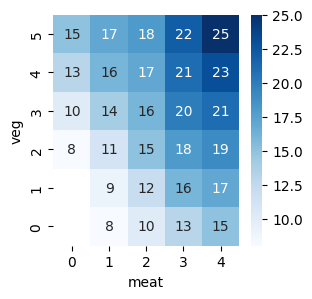

In [3]:
price_flipped = price_df.iloc[::-1]
plt.figure(figsize=(3,3))
sns.heatmap(price_flipped,cmap='Blues',annot=True)
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
x=arr['meat']
y=arr['veg']
z=arr['price']
X = np.vstack((x, y)).T

model = LinearRegression()
model.fit(X, z)

Predicted_price = model.predict(X)
Residuals = z - Predicted_price
print(model.coef_,model.intercept_)

[2.65021645 1.86796537] 5.062770562770561


In [5]:
dtype = [('meat', int), ('veg', int), ('residual', int)]
arr = np.array([(x[i], y[i], Residuals[i]) for i in range(28)], dtype=dtype)
res = pd.DataFrame(arr).pivot(index='veg', columns='meat', values='residual')
res_flipped = res.iloc[::-1]

dtype = [('meat', int), ('veg', int), ('residual', float)]
arr = np.array([(x[i], y[i], Residuals[i]) for i in range(28)], dtype=dtype)
resf = pd.DataFrame(arr).pivot(index='veg', columns='meat', values='residual')
resf_flipped = resf.iloc[::-1]

residualR=Residuals.round()
dtype = [('meat', int), ('veg', int), ('residual', int)]
arr = np.array([(x[i], y[i], residualR[i]) for i in range(28)], dtype=dtype)
resr = pd.DataFrame(arr).pivot(index='veg', columns='meat', values='residual')
resr_flipped = resr.iloc[::-1]

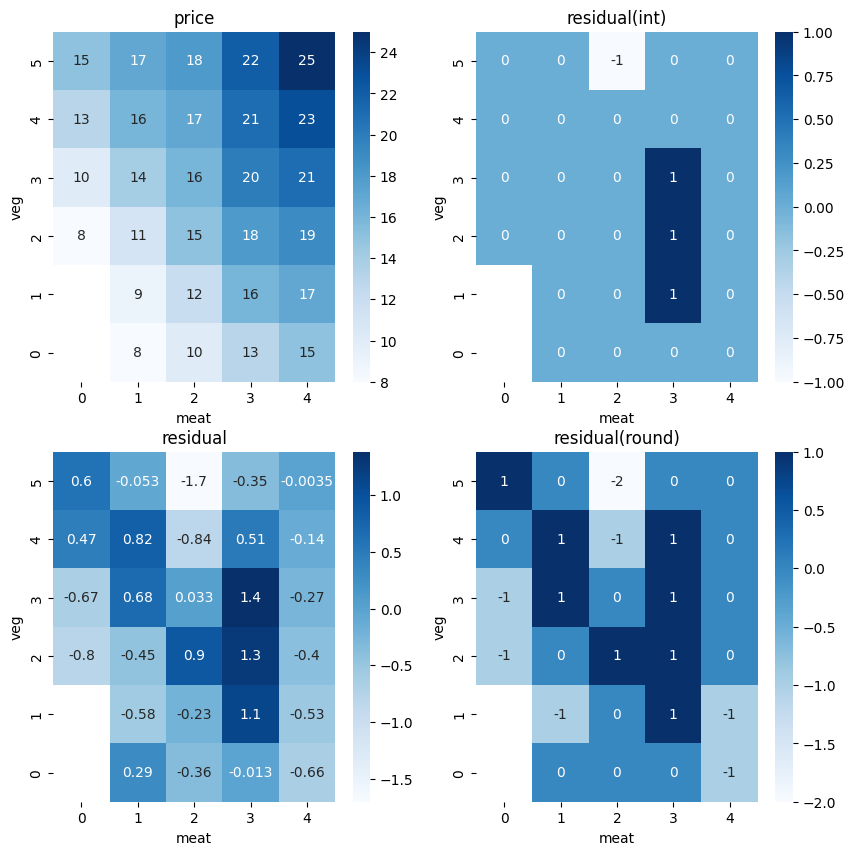

In [6]:
plt.figure(figsize=(10,10))
plt.subplot(2, 2, 1) 
sns.heatmap(price_flipped,cmap='Blues',annot=True)
plt.title('price')
plt.subplot(2, 2, 2) 
sns.heatmap(res_flipped,cmap='Blues',annot=True)
plt.title('residual(int)')
plt.subplot(2, 2, 3) 
sns.heatmap(resf_flipped,cmap='Blues',annot=True)
plt.title('residual')
plt.subplot(2, 2, 4) 
sns.heatmap(resr_flipped,cmap='Blues',annot=True)
plt.title('residual(round)')
plt.show()